In [1]:
from lgdo.lh5 import LH5Store, ls, show, load_dfs

from dspeed.vis import WaveformBrowser
from dspeed import units
from dspeed import build_dsp
import numpy as np
import pandas as pd


from scipy import stats


import matplotlib.pyplot as plt
import os , json


import pint
u = pint.get_application_registry()


import os

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 12


import legendstyles

plt.style.use(legendstyles.LEGEND)



In [2]:

#Note, this just means data file entry for the simulation results you get from the other preprocessing file


df_summary_15_40 = pd.read_pickle("df_summary_PRL_15.pkl")
df_summary_20_40 = pd.read_pickle("df_summary_PRL_20.pkl")
df_summary_25_40 = pd.read_pickle("df_summary_PRL_25.pkl")
df_summary_30_40 = pd.read_pickle("df_summary_PRL_30.pkl")
df_summary_40_40 = pd.read_pickle("df_summary_PRL_40.pkl")
df_summary_50_40 = pd.read_pickle("df_summary_PRL_50.pkl")
df_summary_60_40 = pd.read_pickle("df_summary_PRL_60.pkl")

df_summary_15_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_15_raw.pkl")
df_summary_20_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_20_raw.pkl")
df_summary_25_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_25_raw.pkl")
df_summary_30_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_30_raw.pkl")
df_summary_40_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_40_raw.pkl")
df_summary_50_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_50_raw.pkl")
df_summary_60_raw = pd.read_pickle("PRL_Processed/df_summary_PRL_60_raw.pkl")




detector_locations = pd.read_excel("L200_Det_Radii_Pos.xlsx")


#This just extracts the columns so I can pull this information later 

location_lookup = detector_locations.set_index("Detector_ID")[["X (mm)", "Y (mm)", "Z (mm)"]]




In [3]:
files = {
    "15": "df_summary_PRL_15.pkl",
    "20": "df_summary_PRL_20.pkl",
    "25": "df_summary_PRL_25.pkl",
    "30": "df_summary_PRL_30.pkl",
    "40": "df_summary_PRL_40.pkl",
    "50": "df_summary_PRL_50.pkl",
    "60": "df_summary_PRL_60.pkl",
}

Global detector efficiency by charge:

Charge =  15 : efficiency = 0.8486
Charge =  20 : efficiency = 0.7464
Charge =  25 : efficiency = 0.5449
Charge =  30 : efficiency = 0.2855
Charge =  40 : efficiency = 0.0469
Charge =  50 : efficiency = 0.0133
Charge =  60 : efficiency = 0.0056


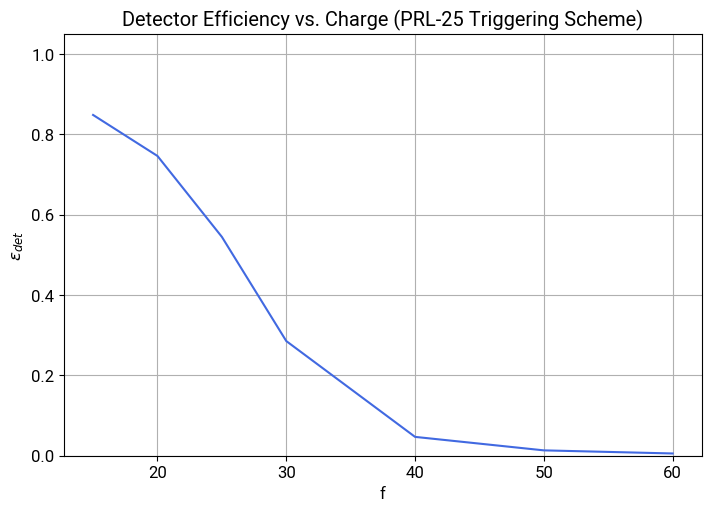

In [4]:
raw_dfs = {
    15: df_summary_15_raw,
    20: df_summary_20_raw,
    25: df_summary_25_raw,
    30: df_summary_30_raw,
    40: df_summary_40_raw,
    50: df_summary_50_raw,
    60: df_summary_60_raw,
}

cut_dfs = {
    15: df_summary_15_40,
    20: df_summary_20_40,
    25: df_summary_25_40,
    30: df_summary_30_40,
    40: df_summary_40_40,
    50: df_summary_50_40,
    60: df_summary_60_40,
}




def detector_efficiency(df_raw, df_cut):
    keys = ["evtid", "detector_id"]

    raw_pairs = df_raw[keys].drop_duplicates()
    cut_pairs = df_cut[keys].drop_duplicates()

    denom = raw_pairs.groupby("detector_id").size()
    numer = cut_pairs.groupby("detector_id").size()

    eff = (
        denom.to_frame("N_before")
        .join(numer.rename("N_after"), how="left")
        .fillna(0)
    )

    eff["efficiency"] = eff["N_after"] / eff["N_before"]
    return eff


eff_by_charge = {}

for q in raw_dfs:
    eff_by_charge[q] = detector_efficiency(
        raw_dfs[q],
        cut_dfs[q]
    )


global_eff = {
    q: eff["N_after"].sum() / eff["N_before"].sum()
    for q, eff in eff_by_charge.items()
}

global_eff = pd.Series(global_eff, name="efficiency")


for q, eff in eff_by_charge.items():
    assert (eff["N_after"] <= eff["N_before"]).all(), f"Bad counts at Q={q}"
    assert (eff["efficiency"] <= 1).all(), f"Efficiency > 1 at Q={q}"



print("Global detector efficiency by charge:\n")

for q, eff in global_eff.items():
    print(f"Charge = {q:>3} : efficiency = {eff:.4f}")




import matplotlib.pyplot as plt

# Extract charge and efficiency
charges = global_eff.index
efficiencies = global_eff.values

# Plot
plt.figure(figsize=(7,5))
plt.plot(charges, efficiencies, linestyle='-', color='royalblue')
plt.xlabel("f")
plt.ylabel(r"$\epsilon_{det}$")
plt.title("Detector Efficiency vs. Charge (PRL-25 Triggering Scheme)")
plt.grid(True)
plt.ylim(0, 1.05)  # Ensure efficiency axis goes up to 1
plt.show()

In [5]:
# 5 meter radius (A_Omega) = pi^2 * r^2, units are in Sr-1 Cm-2 
# 25 m^2 = 250000 cm ^2


def effective_solid_angle(N_m, N_total):
    return 250000*np.pi*np.pi * (N_m / N_total)

# Empty Results
solid_angle_results = {}

# Loop over all files
for label, filename in files.items():
    # Load file
    df_summary = pd.read_pickle(filename)

    #Take first hit per particle
    first_hits = (
        df_summary
        .sort_values("entry_time")
        .groupby("evtid")
        .first()
        .reset_index()
    )

    #N_total = len(first_hits)
    N_total = 100000000

    #Calculate total solid angle covered for each multiplicity
    solid_angle_by_mult = {}
    for m in range(1,10,1):
        N_m = (first_hits["multiplicity"] == m).sum()
        Omega_eff = effective_solid_angle(N_m, N_total)
        solid_angle_by_mult[m] = Omega_eff
    #Convert to a dataframe
    solid_angle_df = pd.DataFrame({
        "multiplicity": list(solid_angle_by_mult.keys()),
        "solid_angle_sr": list(solid_angle_by_mult.values())
    }).sort_values("multiplicity")

    globals()[f"solid_angle_df_{label}"] = solid_angle_df


    # Sanity check: sum over ALL multiplicities should be 2*pi
    Omega_sum = solid_angle_df["solid_angle_sr"].sum()

    print(f"{label}: N_total={N_total}")
    print(solid_angle_df[["multiplicity", "solid_angle_sr"]].to_string(index=False))
    print(f"Sum Omega over all m = {Omega_sum:.6f}")
    print()

15: N_total=100000000
 multiplicity  solid_angle_sr
            1     6096.800075
            2     3824.767794
            3     1039.145973
            4      275.633377
            5       74.416817
            6       24.599989
            7        7.920358
            8        3.701102
            9        1.677833
Sum Omega over all m = 11348.663317

20: N_total=100000000
 multiplicity  solid_angle_sr
            1     5192.127461
            2     3439.211698
            3      934.207405
            4      244.815537
            5       67.137984
            6       22.453350
            7        7.204811
            8        3.651754
            9        1.603811
Sum Omega over all m = 9912.413810

25: N_total=100000000
 multiplicity  solid_angle_sr
            1     3678.771670
            2     2586.773966
            3      675.327681
            4      171.410354
            5       47.053339
            6       16.630283
            7        5.699697
            8        

20: N_total=100000000
 multiplicity  solid_angle_sr
            1     5192.127461
            2     3439.211698
            3      934.207405
            4      244.815537
            5       67.137984
            6       22.453350
            7        7.204811
            8        3.651754
            9        1.603811
Sum Omega over all m = 9912.413810



25: N_total=100000000
 multiplicity  solid_angle_sr
            1     3678.771670
            2     2586.773966
            3      675.327681
            4      171.410354
            5       47.053339
            6       16.630283
            7        5.699697
            8        2.615445
            9        1.529789
Sum Omega over all m = 7185.812224

30: N_total=100000000
 multiplicity  solid_angle_sr
            1     1816.451342
            2     1411.501473
            3      356.662829
            4       82.386523
            5       24.822055
            6        9.104710
            7        3.553058
            8        1.406419
            9        0.838916
Sum Omega over all m = 3706.727325



40: N_total=100000000
 multiplicity  solid_angle_sr
            1      304.674688
            2      232.675924
            3       52.210207
            4       14.360274
            5        4.934802
            6        1.653159
            7        0.740220
            8        0.271414
            9        0.148044
Sum Omega over all m = 611.668733

50: N_total=100000000
 multiplicity  solid_angle_sr
            1      110.218807
            2       65.460151
            3       11.103305
            4        2.516749
            5        0.888264
            6        0.246740
            7        0.049348
            8        0.074022
            9        0.000000
Sum Omega over all m = 190.557387

60: N_total=100000000
 multiplicity  solid_angle_sr
            1       57.885230
            2       24.994773
            3        3.330991
            4        0.986960
            5        0.172718
            6        0.000000
            7        0.024674
            8        0.0

In [6]:
import numpy as np
import pandas as pd
from itertools import combinations

def angular_diff(a, b):
    diff = a - b
    return (diff + np.pi) % (2 * np.pi) - np.pi


def compute_std_devs(df_summary, location_lookup):
    hits_sorted = df_summary.sort_values(
        ["evtid", "z_entry"], ascending=[True, False]
    )

    detectors_by_event = (
        hits_sorted
        .groupby("evtid")
        .apply(lambda g: list(zip(g["detector_id"], g["total_edep"])))
        .reset_index(name="det_edep")
    )

    detectors_by_event = detectors_by_event[
        detectors_by_event["det_edep"].apply(len) >= 3
    ]

    rows = []

    for _, row in detectors_by_event.iterrows():
        evtid = row["evtid"]
        det_edep = row["det_edep"]

        det_ids = [d for d, _ in det_edep]
        edeps = [e for _, e in det_edep]

        try:
            pos = np.array([location_lookup.loc[d].values for d in det_ids])
        except KeyError:
            continue

        for i, j in combinations(range(len(det_ids)), 2):
            vec = pos[j] - pos[i]
            norm = np.linalg.norm(vec)
            if norm < 1e-10:
                continue

            unit = vec / norm
            omega = edeps[i] + edeps[j]

            rows.append({
                "evtid": evtid,
                "cos_theta": unit[2],
                "phi": np.arctan2(unit[1], unit[0]),
                "omega": omega
            })

    angles = pd.DataFrame(rows)

    # --- averages ---
    avg_cos = (
        angles.groupby("evtid")
        .apply(lambda g: np.sum(g["omega"] * g["cos_theta"]) / np.sum(g["omega"]))
        .rename("avg_cos_theta")
    )

    avg_phi = (
        angles.groupby("evtid")
        .apply(lambda g: np.arctan2(
            np.sum(g["omega"] * np.sin(g["phi"])) / np.sum(g["omega"]),
            np.sum(g["omega"] * np.cos(g["phi"])) / np.sum(g["omega"])
        ))
        .rename("avg_phi")
    )

    angles = angles.join(avg_cos, on="evtid")
    angles = angles.join(avg_phi, on="evtid")

    # --- std devs ---
    angles["cos_sq"] = angles["omega"] * (angles["cos_theta"] - angles["avg_cos_theta"])**2
    angles["phi_sq"] = angles["omega"] * angular_diff(angles["phi"], angles["avg_phi"])**2

    std_devs = (
        angles.groupby("evtid")
        .apply(lambda g: pd.Series({
            "weighted_std_dev_cos_theta": np.sqrt(g["cos_sq"].sum() / g["omega"].sum()),
            "weighted_std_dev_phi": np.sqrt(g["phi_sq"].sum() / g["omega"].sum())
        }))
        .reset_index()
    )

    return std_devs


In [7]:
files = {
    "15": "df_summary_PRL_15.pkl",
    "20": "df_summary_PRL_20.pkl",
    "25": "df_summary_PRL_25.pkl",
    "30": "df_summary_PRL_30.pkl",
    "40": "df_summary_PRL_40.pkl",
    "50": "df_summary_PRL_50.pkl",
    "60": "df_summary_PRL_60.pkl",
}

std_devs_by_charge = {}

for charge, fname in files.items():
    df = pd.read_pickle(fname)
    std_devs = compute_std_devs(df, location_lookup)

    std_devs_by_charge[charge] = std_devs
    #std_devs.to_pickle(f"std_devs_q{charge}.pkl")

    print(f"Computed std_devs for q={charge}")


/tmp/ipykernel_23471/19681651.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(zip(g["detector_id"], g["total_edep"])))
/tmp/ipykernel_23471/19681651.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sum(g["omega"] * g["cos_theta"]) / np.sum(g["omega"]))
/tmp/ipykernel_23471/19681651.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping c

Computed std_devs for q=15


/tmp/ipykernel_23471/19681651.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(zip(g["detector_id"], g["total_edep"])))
/tmp/ipykernel_23471/19681651.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sum(g["omega"] * g["cos_theta"]) / np.sum(g["omega"]))
/tmp/ipykernel_23471/19681651.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping c

Computed std_devs for q=20


/tmp/ipykernel_23471/19681651.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(zip(g["detector_id"], g["total_edep"])))
/tmp/ipykernel_23471/19681651.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sum(g["omega"] * g["cos_theta"]) / np.sum(g["omega"]))
/tmp/ipykernel_23471/19681651.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping c

...

Computed std_devs for q=50


/tmp/ipykernel_23471/19681651.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(zip(g["detector_id"], g["total_edep"])))
/tmp/ipykernel_23471/19681651.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sum(g["omega"] * g["cos_theta"]) / np.sum(g["omega"]))
/tmp/ipykernel_23471/19681651.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping c

Computed std_devs for q=60


/tmp/ipykernel_23471/19681651.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


/tmp/cachapm/32448378/c0412.ll.unc.edu/ipykernel_2414616/19681651.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [8]:
def apply_all_cuts(
    df_summary,
    phi_cut=1.56, #2.1
    cos_cut=0.42, #0.45
    max_mult=7, #8
    energy_cut=176, #190
):
    # multiplicity cut
    df = df_summary[df_summary["multiplicity"] > 2]
    df = df[df["multiplicity"] < max_mult]

    # energy cut per event
    energy_per_evt = df.groupby("evtid")["total_edep"].sum()
    good_evtids = energy_per_evt[energy_per_evt < energy_cut].index
    df = df[df["evtid"].isin(good_evtids)]

    # spatial cut
    df = df[
        (df["weighted_std_dev_phi"] < phi_cut) &
        (df["weighted_std_dev_cos_theta"] < cos_cut)
    ]

    return df


final_dfs = {}
cut_eff = {}


for charge, fname in files.items():
    df = pd.read_pickle(fname)
    std_devs = std_devs_by_charge[charge]

    df_merged = df.merge(std_devs, on="evtid", how="left")

    total_events = df_merged[df_merged["multiplicity"] > 2]["evtid"].nunique()

    df_final = apply_all_cuts(df_merged)

    final_dfs[charge] = df_final

    eps_cut = df_final["evtid"].nunique() / total_events
    cut_eff[int(charge)] = eps_cut

    print(f"q={charge}: {eps_cut*100:.2f}% events passed")



q=15: 9.49% events passed
q=20: 47.27% events passed
q=25: 81.89% events passed
q=30: 93.72% events passed
q=40: 95.99% events passed
q=50: 98.01% events passed
q=60: 98.36% events passed


q=20: 47.99% events passed
q=25: 82.83% events passed


q=30: 94.62% events passed
q=40: 97.18% events passed
q=50: 98.67% events passed
q=60: 99.45% events passed


In [9]:
for label, filename in files.items():
    df_summary = pd.read_pickle(filename)

    first_hits = (
        df_summary
        .sort_values("entry_time")
        .groupby("evtid")
        .first()
        .reset_index()
    )

    #N_total = len(first_hits)
    N_total = 100000000

    solid_angle_by_mult = {}
    for m in range(1, 10):
        N_m = (first_hits["multiplicity"] == m).sum()
        
        solid_angle_by_mult[m] = effective_solid_angle(N_m, N_total)

    solid_angle_df = (
        pd.DataFrame({
            "multiplicity": solid_angle_by_mult.keys(),
            "solid_angle_sr": solid_angle_by_mult.values(),
        })
        .sort_values("multiplicity")
    )

    q = int(label)

    eps_cut = cut_eff[q]

    solid_angle_df["solid_angle_sr_eff"] = (
        solid_angle_df["solid_angle_sr"] * eps_cut
    )

    globals()[f"solid_angle_df_{label}"] = solid_angle_df

    # Sanity checks
    Omega_geom = solid_angle_df["solid_angle_sr"].sum()
    Omega_eff  = solid_angle_df["solid_angle_sr_eff"].sum()

    print(f"Charge {label}")
    print(f"Cut efficiency ε_cut = {eps_cut:.6f}")
    print(solid_angle_df.to_string(index=False))
    print(f"Sum geometric Ω = {Omega_geom:.6f}")
    print(f"Sum accepted  Ω = {Omega_eff:.6f}  (should be 2π × ε_cut)")
    print(f"2π × ε_cut     = {2*np.pi*eps_cut:.6f}")
    print()


Charge 15
Cut efficiency ε_cut = 0.094879
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1     6096.800075          578.460818
            2     3824.767794          362.891727
            3     1039.145973           98.593561
            4      275.633377           26.151933
            5       74.416817            7.060624
            6       24.599989            2.334033
            7        7.920358            0.751479
            8        3.701102            0.351158
            9        1.677833            0.159192
Sum geometric Ω = 11348.663317
Sum accepted  Ω = 1076.754525  (should be 2π × ε_cut)
2π × ε_cut     = 0.596145

Charge 20
Cut efficiency ε_cut = 0.472670
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1     5192.127461         2454.164100
            2     3439.211698         1625.612997
            3      934.207405          441.572032
            4      244.815537          115.717017
            5       67.137984           31.734127
    

Charge 20
Cut efficiency ε_cut = 0.479926
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1     5192.127461         2491.837453
            2     3439.211698         1650.567437
            3      934.207405          448.350511
            4      244.815537          117.493365
            5       67.137984           32.221270
            6       22.453350           10.775949
            7        7.204811            3.457777
            8        3.651754            1.752572
            9        1.603811            0.769711
Sum geometric Ω = 9912.413810
Sum accepted  Ω = 4757.226044  (should be 2π × ε_cut)
2π × ε_cut     = 3.015465



Charge 25
Cut efficiency ε_cut = 0.828288
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1     3678.771670         3047.083312
            2     2586.773966         2142.594455
            3      675.327681          559.365976
            4      171.410354          141.977181
            5       47.053339           38.973727
            6       16.630283           13.774668
            7        5.699697            4.720992
            8        2.615445            2.166342
            9        1.529789            1.267106
Sum geometric Ω = 7185.812224
Sum accepted  Ω = 5951.923760  (should be 2π × ε_cut)
2π × ε_cut     = 5.204288

Charge 30
Cut efficiency ε_cut = 0.946247
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1     1816.451342         1718.810769
            2     1411.501473         1335.628364
            3      356.662829          337.490962
            4       82.386523           77.957961
            5       24.822055           23.487783
     

Charge 40
Cut efficiency ε_cut = 0.971808
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1      304.674688          296.085186
            2      232.675924          226.116238
            3       52.210207           50.738278
            4       14.360274           13.955424
            5        4.934802            4.795678
            6        1.653159            1.606552
            7        0.740220            0.719352
            8        0.271414            0.263762
            9        0.148044            0.143870
Sum geometric Ω = 611.668733
Sum accepted  Ω = 594.424341  (should be 2π × ε_cut)
2π × ε_cut     = 6.106047

Charge 50
Cut efficiency ε_cut = 0.986733
 multiplicity  solid_angle_sr  solid_angle_sr_eff
            1      110.218807          108.756534
            2       65.460151           64.591691
            3       11.103305           10.955997
            4        2.516749            2.483359
            5        0.888264            0.876480
       

/tmp/ipykernel_23471/1599835124.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


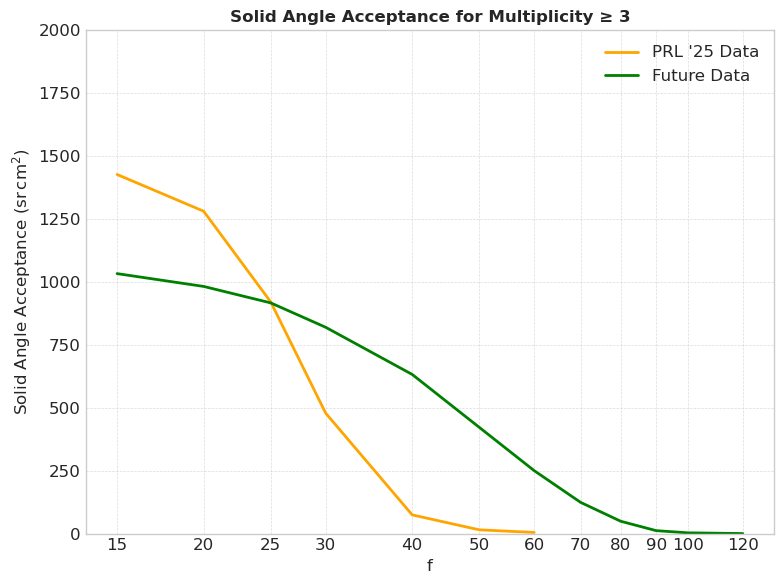

/tmp/ipykernel_23471/1599835124.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


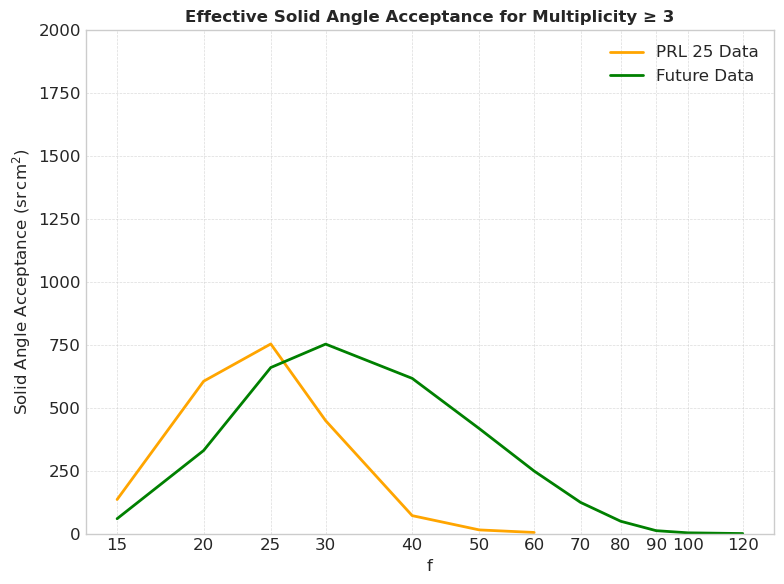

In [11]:
import matplotlib.pyplot as plt


f = [15, 20, 25, 30, 40, 50, 60]

f_P15 = [15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 120]

# Collect solid angle sums for multiplicity >= 3
solid_angle_array = []

solid_angle_array_ef = []



solid_angle_P15 = [1033.150189, 982.223030, 916.738205,  819.966734, 632.468924,  422.048958, 250.169798, 124.134949, 48.977912, 11.670807, 3, 0.1 ]


solid_angle_P15_eff = [59.118930, 330.228668, 659.955772, 753.050816, 616.850275, 417.064808, 248.417943, 123.937557, 48.953238, 11.596785, 3, 0.1]

for charge in f:
    # Access the DataFrame created by your loop above
    df = globals()[f"solid_angle_df_{charge}"]
    
    # Sum solid angles for multiplicity >= 3
    #total_solid_angle = df[df["multiplicity"] >= 3]["solid_angle_sr_eff"].sum()
    total_solid_angle = (df[df["multiplicity"] >= 3]["solid_angle_sr"].sum())
    solid_angle_array.append(total_solid_angle)
    total_solid_angle_eff = (df[df["multiplicity"] >= 3]["solid_angle_sr_eff"].sum())
    solid_angle_array_ef.append(total_solid_angle_eff)

# ------------------------
# Plotting
# ------------------------
plt.figure(figsize=(8, 6))
plt.style.use("seaborn-v0_8-whitegrid")

plt.plot(f, solid_angle_array, color='orange', linewidth=2, markersize=6, label="PRL '25 Data")
#plt.plot(f, solid_angle_array_ef, color='orange', linewidth=2, markersize=6, label='Current Data')
plt.plot(f_P15, solid_angle_P15, color = "green", linewidth =2 , markersize = 6, label = "Future Data")
#plt.plot(f_P15, solid_angle_P15_eff, color = "green", linewidth =2 , markersize = 6, label = "Future Data")

plt.ylim(0, 2000)
plt.xscale("log")  # log scale for charge fraction
plt.xlabel("f")
plt.ylabel(r"Solid Angle Acceptance ($\mathrm{sr}\,\mathrm{cm}^{2}$)")
plt.title("Solid Angle Acceptance for Multiplicity ≥ 3", fontsize=12, weight='bold')

# Ticks and grid
plt.xticks(f_P15, labels=[str(val) for val in f_P15], fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.legend()
plt.show()
#plt.savefig("prl_solid_angle_25_bf.png", dpi=300, bbox_inches="tight")



plt.figure(figsize=(8, 6))
plt.style.use("seaborn-v0_8-whitegrid")


plt.plot(f, solid_angle_array_ef, color='orange', linewidth=2, markersize=6, label="PRL 25 Data")

plt.plot(f_P15, solid_angle_P15_eff, color = "green", linewidth =2 , markersize = 6, label = "Future Data")

plt.ylim(0, 2000)
plt.xscale("log")  # log scale for charge fraction
plt.xlabel("f")
plt.ylabel(r"Solid Angle Acceptance ($\mathrm{sr}\,\mathrm{cm}^{2}$)")
plt.title("Effective Solid Angle Acceptance for Multiplicity ≥ 3", fontsize=12, weight='bold')

# Ticks and grid
plt.xticks(f_P15, labels=[str(val) for val in f_P15], fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.legend()
plt.show()


In [21]:
# SENSITIVITY CALCULATIONS, for real data taking
# 40 keV Thresholds

n = 3.4 # Feldman-Cousins constant
#n = 2.44


t = 0.7 * 3.154e7  # seconds

labels = ["15", "20", "25", "30", "40", "50", "60"]

for label in labels:
    solid_angle_df = globals()[f"solid_angle_df_{label}"]

    # Set multiplicity as index
    product = solid_angle_df.set_index("multiplicity")["solid_angle_sr_eff"]

    print(f"\n=== Charge {label} ===")
    print("Index (multiplicity) -> solid_angle_sr")
    for idx, val in product.items():
        print(f"  index = {idx:2d}  |  Ω_eff = {val:.6e}")

    # Explicitly show what is being summed
    selected = product[product.index > 2]

    print("\nUsed in sensitivity sum (multiplicity > 2):")
    for idx, val in selected.items():
        print(f"  m = {idx:2d}  |  Ω_eff = {val:.6e}")

    sensitivity = n / (t * selected.sum())
    globals()[f"sensitivity_{label}"] = sensitivity

    print(f"\n{label} sensitivity: {sensitivity:.3e}")



=== Charge 15 ===
Index (multiplicity) -> solid_angle_sr
  index =  1  |  Ω_eff = 5.784608e+02
  index =  2  |  Ω_eff = 3.628917e+02
  index =  3  |  Ω_eff = 9.859356e+01
  index =  4  |  Ω_eff = 2.615193e+01
  index =  5  |  Ω_eff = 7.060624e+00
  index =  6  |  Ω_eff = 2.334033e+00
  index =  7  |  Ω_eff = 7.514789e-01
  index =  8  |  Ω_eff = 3.511584e-01
  index =  9  |  Ω_eff = 1.591918e-01

Used in sensitivity sum (multiplicity > 2):
  m =  3  |  Ω_eff = 9.859356e+01
  m =  4  |  Ω_eff = 2.615193e+01
  m =  5  |  Ω_eff = 7.060624e+00
  m =  6  |  Ω_eff = 2.334033e+00
  m =  7  |  Ω_eff = 7.514789e-01
  m =  8  |  Ω_eff = 3.511584e-01
  m =  9  |  Ω_eff = 1.591918e-01

15 sensitivity: 1.137e-09

=== Charge 20 ===
Index (multiplicity) -> solid_angle_sr
  index =  1  |  Ω_eff = 2.454164e+03
  index =  2  |  Ω_eff = 1.625613e+03
  index =  3  |  Ω_eff = 4.415720e+02
  index =  4  |  Ω_eff = 1.157170e+02
  index =  5  |  Ω_eff = 3.173413e+01
  index =  6  |  Ω_eff = 1.061303e+01
  in

In [22]:
# SENSITIVITY CALCULATIONS, for real data taking
# 40 keV Thresholds

n = 2.44 # Feldman-Cousins constant
#n = 2.44


t = 0.7 * 3.154e7  # seconds

labels = ["15", "20", "25", "30", "40", "50", "60"]

for label in labels:
    solid_angle_df = globals()[f"solid_angle_df_{label}"]

    # Set multiplicity as index
    product = solid_angle_df.set_index("multiplicity")["solid_angle_sr"]

    print(f"\n=== Charge {label} ===")
    print("Index (multiplicity) -> solid_angle_sr")
    for idx, val in product.items():
        print(f"  index = {idx:2d}  |  Ω_eff = {val:.6e}")

    # Explicitly show what is being summed
    selected = product[product.index > 2]

    print("\nUsed in sensitivity sum (multiplicity > 2):")
    for idx, val in selected.items():
        print(f"  m = {idx:2d}  |  Ω_eff = {val:.6e}")

    sensitivity_bf = n / (t * selected.sum())
    globals()[f"sensitivity_bf_{label}"] = sensitivity_bf

    print(f"\n{label} sensitivity_bf: {sensitivity_bf:.3e}")



=== Charge 15 ===
Index (multiplicity) -> solid_angle_sr
  index =  1  |  Ω_eff = 6.096800e+03
  index =  2  |  Ω_eff = 3.824768e+03
  index =  3  |  Ω_eff = 1.039146e+03
  index =  4  |  Ω_eff = 2.756334e+02
  index =  5  |  Ω_eff = 7.441682e+01
  index =  6  |  Ω_eff = 2.459999e+01
  index =  7  |  Ω_eff = 7.920358e+00
  index =  8  |  Ω_eff = 3.701102e+00
  index =  9  |  Ω_eff = 1.677833e+00

Used in sensitivity sum (multiplicity > 2):
  m =  3  |  Ω_eff = 1.039146e+03
  m =  4  |  Ω_eff = 2.756334e+02
  m =  5  |  Ω_eff = 7.441682e+01
  m =  6  |  Ω_eff = 2.459999e+01
  m =  7  |  Ω_eff = 7.920358e+00
  m =  8  |  Ω_eff = 3.701102e+00
  m =  9  |  Ω_eff = 1.677833e+00

15 sensitivity_bf: 7.744e-11

=== Charge 20 ===
Index (multiplicity) -> solid_angle_sr
  index =  1  |  Ω_eff = 5.192127e+03
  index =  2  |  Ω_eff = 3.439212e+03
  index =  3  |  Ω_eff = 9.342074e+02
  index =  4  |  Ω_eff = 2.448155e+02
  index =  5  |  Ω_eff = 6.713798e+01
  index =  6  |  Ω_eff = 2.245335e+01
 

In [23]:
MAJORANA_f = [
    6.1441556661801044,
    16.953358528675174,
    33.95090254551493,
    50.23219575971994,
    80.76093918330527,
    125.30087944352053,
    200.26062970407807,
    387.0122528127932,
    688.2805433521115,
    965.3763865872353
]

MAJORANA_s = [
    2.03318127174144e-9,
    2.1544346900318866e-9,
    2.4190664525741175e-9,
    4.074392775323614e-9,
    1.0293868508027706e-8,
    5.522533573417251e-8,
    4.4442526713836357e-7,
    4.777990512153967e-6,
    2.878190244668798e-5,
    9.16777932442607e-5
]




CUORE_f = [
    24.546809462497595,
    17.390571415117027,
    11.937143995159651,
    8.403743518652893,
    4.086750933306106,
    2.849908135223522,
    1.9873920656678443
]

CUORE_s = [
    3.926986478874697e-10,
    2.6052030872682683e-11,
    6.787083125912116e-12,
    9.77460035646153e-12,
    1.0466512108254266e-11,
    8.332821508477356e-12,
    3.2722877394666835e-10
]

CDMS_f = [
    6.107795256022604,
    14.61545186976725,
    25.68606309502903,
    33.35170986162733,
    43.048787437016195,
    66.00216804713888,
    84.18709826237493,
    121.63692127407721,
    192.11063060917544
]

CDMS_s = [
    1.0907766915109565e-8,
    1.0293868508027706e-8,
    1.0907766915109565e-8,
    9.301510038746647e-8,
    1.9187520990478363e-5,
    0.10750942544107057,
    6.570676154824845,
    1279.140468361965,
    666652.2835319515
]


CDMSLite_f = [
    102.04034770855627,
    127.42749857031335,
    149.77474763452,
    202.77646319126458,
    291.68378082484196,
    394.9037229576702,
    628.4136559286959,
    817.1103315457203,
    980.0045006276945
]

CDMSLite_s = [
    2.424462017082331e-7,
    1.584893192461114e-7,
    1.1937766417144357e-7,
    1.3755029890088556e-7,
    1.960232982646277e-7,
    3.2187875118212356e-7,
    6.089973244419447e-7,
    1.0734188827013527e-6,
    1.3276295892211254e-6
]



/tmp/ipykernel_1688440/23247003.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


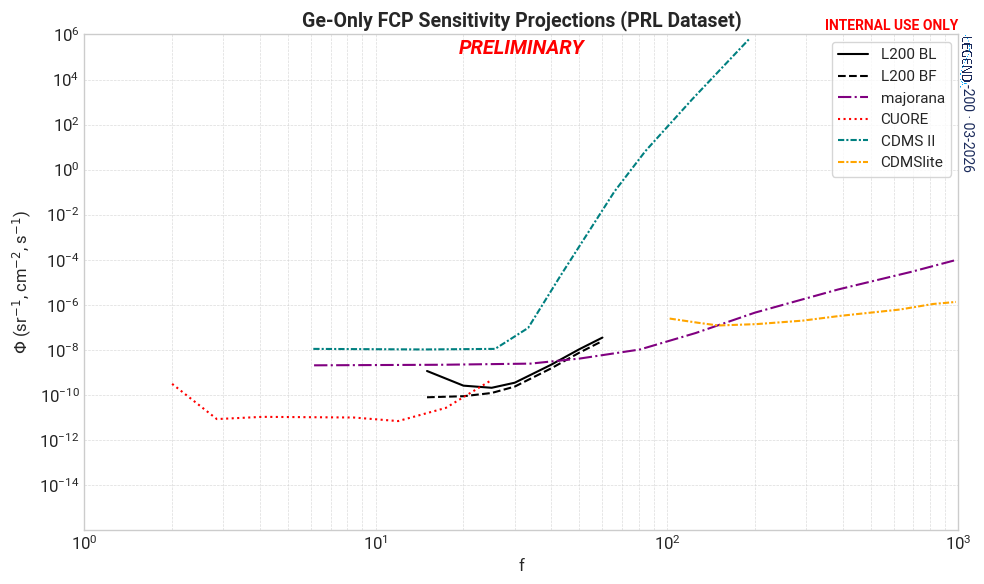

In [24]:
import matplotlib.pyplot as plt
import numpy as np

f = [15, 20, 25, 30, 40, 50, 60]
sensitivity = [sensitivity_15, sensitivity_20, sensitivity_25,
               sensitivity_30, sensitivity_40, sensitivity_50,
               sensitivity_60]


sensitivity_bf = [
    sensitivity_bf_15,
    sensitivity_bf_20,
    sensitivity_bf_25,
    sensitivity_bf_30,
    sensitivity_bf_40,
    sensitivity_bf_50,
    sensitivity_bf_60
]

plt.style.use(legendstyles.LEGEND)

# Figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Main plot lines
ax.plot(f, sensitivity, linestyle='-', color='black', label="L200 BL")
ax.plot(f, sensitivity_bf, linestyle = '--', color = 'black', label = "L200 BF")

ax.plot(MAJORANA_f, MAJORANA_s, linestyle='-.', color='purple', label="majorana")
ax.plot(CUORE_f, CUORE_s, linestyle=':', color='red', label="CUORE")
ax.plot(CDMS_f, CDMS_s, linestyle=(0, (3, 1, 1, 1)), color="#008080", label="CDMS II")
ax.plot(CDMSLite_f, CDMSLite_s, linestyle=(0, (3, 1, 1, 1)), color="orange", label="CDMSlite")


# Axes scaling and limits
ax.set_xscale("log")
ax.set_xlim(1, 1000)
ax.set_yscale("log")
ax.set_ylim(1e-16, 1e6)

ax.set_yticks([1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6])

ax.grid(True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

# Proper axis labels and title
ax.set_xlabel("f", fontsize=12)
ax.set_ylabel(r"$\Phi$ (sr$^{-1}$, cm$^{-2}$, s$^{-1}$)", fontsize=12)
ax.set_title("Ge-Only FCP Sensitivity Projections (PRL Dataset)", fontsize=14, weight='bold')

#ax.vlines(23, 10^-14, 10^2)
#ax.vlines(43, 10^-14, 10^2)



# Legend and watermark
ax.legend(frameon=True, loc='best', fontsize=11)
legendstyles.legend_watermark(ax, logo_suffix="-200")
legendstyles.add_preliminary(ax, color="red")

plt.tight_layout()

plt.savefig("prl_sensititvity_25_FINAL.png", dpi=300, bbox_inches="tight")
plt.show()
